# Deus Ex Machina - Project CS4
## (De)Generative AI

### Group components

- Catarina Monteiro
- Diogo Mendes
- Gonçalo Brochado
- Guilherme Vaz
- Matheus Bissacot

## Introduction

The case study presented in the article "Generative AI Bias: A Growing Concern in the Industry" by Bloomberg examines the biases inherent in generative AI models, particularly focusing on Stable Diffusion. It highlights how these models often misrepresent racial and gender demographics in their outputs, perpetuating harmful stereotypes.

For instance, the study found that women and people of color are significantly underrepresented in high-paying occupations within the generated images, while individuals with lighter skin tones dominate the portrayals of such roles.

In this Notebook, using a dataset with a similar dilemma, we want to prove how Data Quality is crucial to avoid these very serious problems.

## Dataset
(Escrever outra descrição)

COMPAS (Correctional Offender Management Profiling for Alternative Sanctions) is a popular commercial algorithm used by judges and parole officers for scoring criminal defendant’s likelihood of reoffending (recidivism). It has been shown that the algorithm is biased in favor of white defendants, and against black inmates, based on a 2 year follow up study (i.e who actually committed crimes or violent crimes after 2 years). The pattern of mistakes, as measured by precision/sensitivity is notable.
 
https://www.kaggle.com/datasets/danofer/compass?select=compas-scores-raw.csv

## Requirements
(Anotar quais programas e quais versões são necessárias)

- Python 3.11.7
- Pandas 2.0.1  ?  2.2.3
- ydata-profiling 4.11.0  ? 4.12.0
- scikit-learn ?  1.5.2
- numpy ?  2.0.2
- scipy ?  1.13.1
- seaborn ?  0.13.2
- ipywidgets ? 8.1.5


## Data Analysis

Let's start with the basic analysis of the dataset

In [1]:
import pandas as pd

# Load the data
df = pd.read_csv('archive/compas-scores-raw.csv')

In [2]:
df.head()

,Person_ID,AssessmentID,Case_ID,Agency_Text,LastName,FirstName,MiddleName,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,...,RecSupervisionLevel,RecSupervisionLevelText,Scale_ID,DisplayText,RawScore,DecileScore,ScoreText,AssessmentType,IsCompleted,IsDeleted
0,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,7,Risk of Violence,-2.08,4,Low,New,1,0
1,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,8,Risk of Recidivism,-1.06,2,Low,New,1,0
2,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,18,Risk of Failure to Appear,15.00,1,Low,New,1,0
3,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,7,Risk of Violence,-2.84,2,Low,New,1,0
4,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,8,Risk of Recidivism,-1.50,1,Low,New,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60843 entries, 0 to 60842
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person_ID                60843 non-null  int64  
 1   AssessmentID             60843 non-null  int64  
 2   Case_ID                  60843 non-null  int64  
 3   Agency_Text              60843 non-null  object 
 4   LastName                 60843 non-null  object 
 5   FirstName                60843 non-null  object 
 6   MiddleName               15624 non-null  object 
 7   Sex_Code_Text            60843 non-null  object 
 8   Ethnic_Code_Text         60843 non-null  object 
 9   DateOfBirth              60843 non-null  object 
 10  ScaleSet_ID              60843 non-null  int64  
 11  ScaleSet                 60843 non-null  object 
 12  AssessmentReason         60843 non-null  object 
 13  Language                 60843 non-null  object 
 14  LegalStatus           

In [4]:
df.describe()

,Person_ID,AssessmentID,Case_ID,ScaleSet_ID,RecSupervisionLevel,Scale_ID,RawScore,DecileScore,IsCompleted,IsDeleted
count,60843.000000,60843.000000,60843.000000,60843.000000,60843.000000,60843.000000,60843.000000,60843.000000,60843.0,60843.0
mean,53683.206154,68061.029190,60209.128149,21.819536,1.630048,11.000000,5.081457,3.571701,1.0,0.0
std,14363.648515,7320.208226,9638.501654,0.932614,0.944220,4.966596,10.080518,2.617854,0.0,0.0
min,656.000000,649.000000,350.000000,17.000000,1.000000,7.000000,-4.790000,-1.000000,1.0,0.0
25%,52039.000000,62582.000000,56021.000000,22.000000,1.000000,7.000000,-2.090000,1.000000,1.0,0.0
50%,57321.000000,68229.000000,61261.000000,22.000000,1.000000,8.000000,-0.710000,3.000000,1.0,0.0
75%,62748.000000,73870.000000,66554.000000,22.000000,2.000000,18.000000,14.000000,5.000000,1.0,0.0
max,68608.000000,79678.000000,72045.000000,22.000000,4.000000,18.000000,51.000000,10.000000,1.0,0.0


In [5]:
missing_data = df.isnull().sum()
missing_data[missing_data > 0]

MiddleName    45219
ScoreText        45
dtype: int64

Now let's see some interesting statistics related to the social aspects of the dataset

### Understanding the correlation between Age and DecileScore

In [6]:
df['Screening_Date'] = pd.to_datetime(df['Screening_Date'], errors='coerce')
df['DateOfBirth'] = pd.to_datetime(df['DateOfBirth'], errors='coerce')

C:\Users\diogo\AppData\Local\Temp\ipykernel_7004\1131473584.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Screening_Date'] = pd.to_datetime(df['Screening_Date'], errors='coerce')
C:\Users\diogo\AppData\Local\Temp\ipykernel_7004\1131473584.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DateOfBirth'] = pd.to_datetime(df['DateOfBirth'], errors='coerce')


In [7]:
from scipy.stats import pearsonr

df['Age_at_Screening'] = (df['Screening_Date'] - df['DateOfBirth']).dt.days // 365
age_correlation, _ = pearsonr(df['Age_at_Screening'].dropna(), df['DecileScore'])

In [8]:
age_correlation

np.float64(0.20313960306797033)

### Summary of Important Categorical Variables

In [9]:
df['Sex_Code_Text'].value_counts()

Sex_Code_Text
Male      47514
Female    13329
Name: count, dtype: int64

In [10]:
df['Ethnic_Code_Text'].value_counts()

Ethnic_Code_Text
African-American    27018
Caucasian           21783
Hispanic             8742
Other                2592
Asian                 324
Native American       219
Arabic                 75
African-Am             51
Oriental               39
Name: count, dtype: int64

In [11]:
df['ScoreText'].value_counts()

ScoreText
Low       41487
Medium    12488
High       6823
Name: count, dtype: int64

### Racial Groups Percentage

In [12]:
total_defendants = len(df)

for race in df['Ethnic_Code_Text'].unique():
    percent = (len(df[df['Ethnic_Code_Text'] == race]) / total_defendants) * 100
    print(f"{race} defendants: {percent:.2f}%")

Caucasian defendants: 35.80%
African-American defendants: 44.41%
Hispanic defendants: 14.37%
Other defendants: 4.26%
Asian defendants: 0.53%
African-Am defendants: 0.08%
Native American defendants: 0.36%
Oriental defendants: 0.06%
Arabic defendants: 0.12%


### Gender Percentage

In [13]:
for gender in df['Sex_Code_Text'].unique():
    percent = (len(df[df['Sex_Code_Text'] == gender]) / total_defendants) * 100
    print(f"{gender}: {percent:.2f}%")

Male: 78.09%
Female: 21.91%


### DecileScore distribution for Race

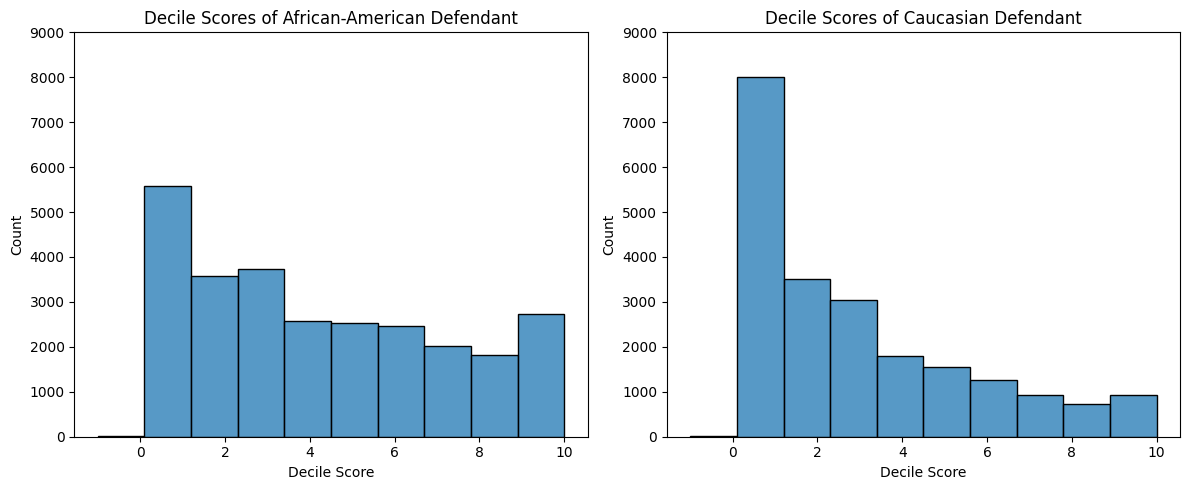

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

sns.histplot(df[df['Ethnic_Code_Text'] == 'African-American']['DecileScore'].dropna(), bins=10, kde=False, ax=ax1)
ax1.set_title("Decile Scores of African-American Defendant")
ax1.set_xlabel("Decile Score")
ax1.set_ylim(0, 9000)

sns.histplot(df[df['Ethnic_Code_Text'] == 'Caucasian']['DecileScore'].dropna(), bins=10, kde=False, ax=ax2)
ax2.set_title("Decile Scores of Caucasian Defendant")
ax2.set_xlabel("Decile Score")
ax2.set_ylim(0, 9000)

plt.tight_layout()
plt.show()

### Cross-Tables

In [15]:
print("\nCross Table between `Sex_Code_Text` and `Ethnic_Code_Text`:")
print(pd.crosstab(df['Sex_Code_Text'], df['Ethnic_Code_Text']))

print("\nCross Table between `DecileScore` and `Ethnic_Code_Text`:")
print(pd.crosstab(df['DecileScore'], df['Ethnic_Code_Text']))


Cross Table between `Sex_Code_Text` and `Ethnic_Code_Text`:
Ethnic_Code_Text  African-Am  African-American  Arabic  Asian  Caucasian  \
Sex_Code_Text                                                              
Female                     6              5577       3     57       5433   
Male                      45             21441      72    267      16350   

Ethnic_Code_Text  Hispanic  Native American  Oriental  Other  
Sex_Code_Text                                                 
Female                1731               60         9    453  
Male                  7011              159        30   2139  

Cross Table between `DecileScore` and `Ethnic_Code_Text`:
Ethnic_Code_Text  African-Am  African-American  Arabic  Asian  Caucasian  \
DecileScore                                                                
-1                         0                16       0      0         18   
 1                         7              5580      26    171       8003   
 2                 

## Data Profiling
(Ver se será realmente necessário)

After a basic analysis, let's do a Profile Report using **ydata_profiling**:

In [16]:
from ydata_profiling import ProfileReport

In [17]:
# Generate the Report
profile = ProfileReport(df,title="COMPAS Recidivism Racial Bias")

In [18]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

The main points are:

- There are approximately 2,7% of missing data, totaling 45.264 cells. The column **MiddleName** has the most missing values with 74,3%
- There is no duplicates in the datasets, which indicates that the each register probably represents a single entry
- There are a lot of imbalanced categorical variables
- **IsCompleted** and **IsDeleted** has only one value
- The variable indicating ethnicity presents values ​​for several groups, with a predominance of "African-American" and "Caucasian"
- The risk score (ScoreText) and the numerical score (DecileScore) are the main targets of analysis to understand possible racial biases. These variables are correlated with each other and are indicative of how the COMPAS model assesses the risk of recidivism, and may reflect bias.

After these observations, we can clean some data to our analysis

First, let's remove columns that are IDs or that don't add predictive value

In [19]:
df = df.drop(columns=['Person_ID', 'AssessmentID', 'Case_ID', 'LastName', 'FirstName', 'MiddleName'])

Since we already removed the 'MiddleName' column, the one with the most missing values, we don't need to remove the others ones.

Nevertheless, the missing data should be replaced for something. In our case, we are doing the standard approach of filling the blanks with the median and mode.

In [20]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [21]:
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

Using the Label Encoding for columns with categories, we can automate the process of encoding categorical columns

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

Now that we did the data cleaning, we can start to do the Logistic Regression

In [23]:
import pandas as pd

df['crime_factor'] = df['DecileScore'].astype('category')


In [24]:
df['Screening_Date'] = pd.to_datetime(df['Screening_Date'], errors='coerce')
df['DateOfBirth'] = pd.to_datetime(df['DateOfBirth'], errors='coerce')

df['age_factor'] = (df['Screening_Date'] - df['DateOfBirth']).dt.days // 365
df['age_factor'] = pd.Categorical(df['age_factor'])

categories = list(df['age_factor'].cat.categories)

if '1' in categories:
    categories.remove('1')
categories = ['1'] + categories

In [25]:
df['race_factor'] = pd.Categorical(df['Ethnic_Code_Text'])

first_race_level = df['race_factor'].cat.categories[0]
df['race_factor'] = df['race_factor'].cat.reorder_categories(
    [first_race_level] + [cat for cat in df['race_factor'].cat.categories if cat != first_race_level],
    ordered=True
)

In [26]:
df['gender_factor'] = pd.Categorical(df['Sex_Code_Text'].replace({"Female": "Female", "Male": "Male"}))

if 'Male' in df['gender_factor'].cat.categories and 'Female' in df['gender_factor'].cat.categories:
    df['gender_factor'] = df['gender_factor'].cat.reorder_categories(['Male', 'Female'], ordered=True)

In [27]:
df['score_factor'] = df['ScoreText'].apply(lambda x: 'LowScore' if x == 'Low' else 'HighScore')

In [28]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.logit('score_factor ~ gender_factor + age_factor + race_factor + crime_factor', data=df)

result = model.fit()

c:\Users\diogo\anaconda3\envs\IAS\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\diogo\anaconda3\envs\IAS\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\diogo\anaconda3\envs\IAS\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\diogo\anaconda3\envs\IAS\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparat

         Current function value: 0.000000
         Iterations: 35


c:\Users\diogo\anaconda3\envs\IAS\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\diogo\anaconda3\envs\IAS\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\diogo\anaconda3\envs\IAS\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\diogo\anaconda3\envs\IAS\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [29]:
result.summary()

c:\Users\diogo\anaconda3\envs\IAS\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\diogo\anaconda3\envs\IAS\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\diogo\anaconda3\envs\IAS\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\diogo\anaconda3\envs\IAS\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparat

<class 'statsmodels.iolib.summary.Summary'>
"""
                              Logit Regression Results                             
===================================================================================
Dep. Variable:     score_factor[HighScore]   No. Observations:                60843
Model:                               Logit   Df Residuals:                    60754
Method:                                MLE   Df Model:                           88
Date:                     Fri, 15 Nov 2024   Pseudo R-squ.:                     inf
Time:                             11:18:24   Log-Likelihood:            -7.2406e-08
converged:                           False   LL-Null:                        0.0000
Covariance Type:                 nonrobust   LLR p-value:                     1.000
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             24.1110   1.37e+05      0.000      1.000   -2.68e+05    2.68e+05
gender_factor[T.1]     2.6299   8901.414      0.000      1.000   -1.74e+04    1.74e+04
age_factor[T.-60]      0.0313   6.78e+04   4.62e-07      1.000   -1.33e+05    1.33e+05
age_factor[T.-59]      0.5722   7.11e+04   8.05e-06      1.000   -1.39e+05    1.39e+05
age_factor[T.-58]      0.1650   6.56e+04   2.52e-06      1.000   -1.29e+05    1.29e+05
age_factor[T.-57]      0.5607    6.7e+04   8.37e-06      1.000   -1.31e+05    1.31e+05
age_factor[T.-56]     -0.0028   6.54e+04  -4.27e-08      1.000   -1.28e+05    1.28e+05
age_factor[T.-55]     -0.0808   6.47e+04  -1.25e-06      1.000   -1.27e+05    1.27e+05
age_factor[T.-54]     -0.0081   6.79e+04  -1.19e-07      1.000   -1.33e+05    1.33e+05
age_factor[T.-53]     -0.0825   6.56e+04  -1.26e-06      1.000   -1.29e+05    1.29e+05
age_factor[T.-52]     -0.0944   6.66e+04  -1.42e-06      1.000   -1.31e+05    1.31e+05
age_factor[T.-51]     -0.1711   6.41e+04  -2.67e-06      1.000   -1.26e+05    1.26e+05
age_factor[T.-50]     -0.1421   6.59e+04  -2.16e-06      1.000   -1.29e+05    1.29e+05
age_factor[T.-49]      0.0353   6.86e+04   5.14e-07      1.000   -1.34e+05    1.34e+05
age_factor[T.-48]      0.0500   6.77e+04   7.39e-07      1.000   -1.33e+05    1.33e+05
age_factor[T.-47]      0.0166   7.07e+04   2.35e-07      1.000   -1.39e+05    1.39e+05
age_factor[T.-46]      0.0742   7.23e+04   1.03e-06      1.000   -1.42e+05    1.42e+05
age_factor[T.-45]      0.3309   7.76e+04   4.26e-06      1.000   -1.52e+05    1.52e+05
age_factor[T.-44]     -0.0320   7.63e+04  -4.19e-07      1.000    -1.5e+05     1.5e+05
age_factor[T.-43]     -0.2569   6.96e+04  -3.69e-06      1.000   -1.36e+05    1.36e+05
age_factor[T.-42]     -0.3660   7.07e+04  -5.18e-06      1.000   -1.39e+05    1.39e+05
age_factor[T.-41]     -0.1550    8.3e+04  -1.87e-06      1.000   -1.63e+05    1.63e+05
age_factor[T.-40]     -0.0850   7.99e+04  -1.06e-06      1.000   -1.57e+05    1.57e+05
age_factor[T.-39]     -0.1013   7.83e+04  -1.29e-06      1.000   -1.54e+05    1.54e+05
age_factor[T.-38]     -0.0333   9.08e+04  -3.67e-07      1.000   -1.78e+05    1.78e+05
age_factor[T.-37]     -0.0788   1.03e+05  -7.68e-07      1.000   -2.01e+05    2.01e+05
age_factor[T.-36]      1.1461   1.68e+05   6.84e-06      1.000   -3.28e+05    3.28e+05
age_factor[T.-35]     -0.0092   1.29e+05  -7.15e-08      1.000   -2.53e+05    2.53e+05
age_factor[T.-34]     -0.0177   1.12e+05  -1.58e-07      1.000    -2.2e+05     2.2e+05
age_factor[T.-33]      0.0086   1.14e+05   7.51e-08      1.000   -2.24e+05    2.24e+05
age_factor[T.-32]     -0.2907   2.14e+05  -1.36e-06      1.000   -4.18e+05    4.18e+05
age_factor[T.-31]     -0.2218   1.75e+05  -1.27e-06      1.000   -3.43e+05    3.43e+05
age_factor[T.-30]     -0.1522   1.29e+05  -1.18e-06      1.000   -2.54e+05    2.54e+05
age_factor[T.-29]     -0.0666   2.93e+05  -2.27e-07      1.000  

- **Coeficiente (coef)**: Representa o efeito de cada variável independente sobre a variável dependente. Um valor positivo indica uma relação positiva com a probabilidade de HighScore = 1, enquanto um valor negativo indica uma relação inversa.

- **Erro Padrão (std err)**: O erro padrão dos coeficientes indica a precisão das estimativas. Quanto menor, mais preciso é o coeficiente estimado.

- **Valor-Z (z)**: Mede o número de desvios padrão que o coeficiente está longe de zero. Um valor absoluto maior de z indica que o coeficiente é mais significativo.

- **P-Valor (P>|z|)**: Indica a significância estatística do coeficiente. Geralmente, valores abaixo de 0.05 indicam significância estatística. Neste caso, todos os p-valores são 1.000, sugerindo que nenhuma das variáveis é estatisticamente significativa, o que é um ponto de atenção (vou abordar isso abaixo).

- **Intervalo de Confiança ([0.025, 0.975])**: O intervalo de confiança de 95% dos coeficientes. Um intervalo que não inclui zero indica uma associação significativa, mas aqui todos parecem incluir zero.

## Results Analysis

After checking the output of the logistic regression model is possible to see that the objective was to see what is the score factor based on the gender_factor and multiple levels of age_factor.

With a simple analysis is possible to supose that the model fit the data because the log-likelihood is near 0, which means that the predicted probabilities are closer to the true outcomes. However it could indicate issues on the data because this model objective is minimize errors and maximize the likelihood without reaching extreme values like near 0.




1- **Intercept**: The very large intercept value (24.1110 with high standard error) is not significant. Since it has a p-value of 1.000, it does not provide meaningful information about the baseline log-odds of a high score.

2- **gender_factor[T.1]**: This variable represents the gender factor, with T.1 likely being a level in a categorical encoding (such as male or female, depending on how the encoding was set). However, the coefficient is 2.6299 with a very high standard error (8901.414) and a p-value of 1.000, indicating it is not statistically significant.

3- **age_factor Variables**: The model includes multiple age_factor levels (e.g., age_factor[T.-60], age_factor[T.-59], etc.), each representing a different age group or categorical level for age. None of these levels show statistically significant coefficients (all p-values are 1.000), meaning there is no clear evidence of an age group association with high scores in this model.